# Project: Zürich wie neu

### 1. Introduction

#### 1.1. Research Question

**Question 1:** Which neighborhoods have the highest number of reports per capita?

#### 1.2. Relevance

#### 1.3 Datasets

### 2. Input and Loading

#### 2.1. Imports
xxxx

In [ ]:
# import libaries
import geopandas as gpd
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import mapclassify # for classifying the choropleth map


#### 2.2. Path settings

In [2]:
# paths to raw and processed datasets 
raw_path_neighborhoods = Path("../data/raw/neighborhoods/statistische_quartiere.gpkg")
raw_path_reports = Path("../data/raw/zueri-wie-neu-reports/reports.gpkg")
raw_path_population_zh = Path("../data/raw/population.csv")
processed_path_neighborhoods = Path("../data/processed/neighborhoods_cleaned.gpkg")
processed_path_reports = Path("../data/processed/reports_cleaned.gpkg")
processed_path_population_zh = Path("../data/processed/population_cleaned.csv")


#### 2.3. Loading and Normalizing Functions

In [ ]:
# functions

# loading data while veryfying if file exists
def load_spatial_data(filepath, layer=None):
    """Safely loads spatial data after verifying the file exists."""
    data_path = Path(filepath)
    
    # Defensive check: Does the file exist, and is it actually a file?
    if not data_path.is_file():
        raise FileNotFoundError(f"Missing data, could not find: {data_path.absolute()}")
    
    if data_path.suffix == ".csv":
        return pd.read_csv(data_path)

    elif data_path.suffix in [".gpkg", ".shp", ".geojson"]: #only .gpkg is (besides .csv) in this project
        return gpd.read_file(data_path, layer=layer)

    else:
        raise ValueError(f"Unsupported file type: {data_path.suffix}")





# plotting a choropleth map
def create_choropleth(
    gdf,
    column,
    title,
    legend_title,
    output_path,
    k=5,
    classification="NaturalBreaks",
    cmap="OrRd"
):
    """
    Create a choropleth map using explicit classification (Jenks / Quantiles / etc.).
    
    The map is saved to the output folder via output_path.
    """

    # copy because copy_gdf["class"] = classifier.yb  would change the original dataset
    copy_gdf = gdf.copy()


    # Classification
    if classification == "NaturalBreaks":
        classifier = mapclassify.NaturalBreaks(copy_gdf[column], k=k)
    elif classification == "Quantiles":
        classifier = mapclassify.Quantiles(copy_gdf[column], k=k)
    elif classification == "EqualInterval":
        classifier = mapclassify.EqualInterval(copy_gdf[column], k=k)
    else:
        raise ValueError("Unknown classification method")


    # plot the map
    fig, ax = plt.subplots(figsize=(11, 8))

    copy_gdf.plot(
        column=column,
        scheme=classification,
        k=k,
        cmap=cmap,
        legend=True,
        ax=ax,
        edgecolor="black",
        missing_kwds={
            "color": "lightgrey",
            "label": "No data"
        },
        legend_kwds={
            "title": legend_title,
            "loc": "lower left"
        }
    )
    
    # set a title and plot without axis
    ax.set_title(title)
    ax.set_axis_off()



    # Save the maps to the output folder via output_path
    fig.savefig(output_path, dpi=400) # dpi is the resolution 
    plt.show()

    return classifier


# evtl function for normalizing reports counts by population


#### 2.3. Loading the Datasets

First, we have to chose the relevant layer for the neighborhoods dataset. xxx We see in the section with the downloaded datasets and a given explanation of each layer and attribut that stzh.adm_statistische_quartiere_v is the layer we want.
Now, we can load the datasets.

In [4]:
# try to load the neighborhood dataset with the relevant layer
try:
    neighborhoods = load_spatial_data(raw_path_neighborhoods, layer= "stzh.adm_statistische_quartiere_v") # neighborhoods of Zurich
except Exception as e:
    print(e)
assert len(neighborhoods) > 0, "Failed to load file."

# try to load the reports dataset
try:
    reports =load_spatial_data(raw_path_reports) # reports from Züri Wie Neu
except Exception as e:
    print(e)
assert len(reports) > 0, "Failed to load file."

# try to load the population dataset
try:
    population_zh = load_spatial_data(raw_path_population_zh) # population of neighborhoods of Zurich
except Exception as e:
    print(e)
assert len(population_zh) > 0, "Failed to load file."

### 3. Dataset Exploration

xxxx

#### 3.1. Explore the Dataset Neighborhoods
xxx

In [5]:
# check for shape and correct data types
print(neighborhoods.info())

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   objid     34 non-null     object  
 1   objectid  34 non-null     int32   
 2   qname     34 non-null     object  
 3   qnr       34 non-null     int32   
 4   kname     34 non-null     object  
 5   knr       34 non-null     int32   
 6   geometry  34 non-null     geometry
dtypes: geometry(1), int32(3), object(3)
memory usage: 1.6+ KB
None


In [6]:
# have a look at what is inside neighborhoods (columns and entries)
display(neighborhoods.head())

,objid,objectid,qname,qnr,kname,knr,geometry
0,1,1,Alt-Wiedikon,31,Kreis 3,3,"POLYGON ((2680606.662 1247034.584, 2680626.356..."
1,10,2,Witikon,74,Kreis 7,7,"POLYGON ((2685858.632 1246502.629, 2685860.738..."
2,11,3,Langstrasse,42,Kreis 4,4,"POLYGON ((2681313.304 1248613.857, 2681459.605..."
3,12,4,Escher Wyss,52,Kreis 5,5,"POLYGON ((2680009.144 1249565.021, 2680055.843..."
4,13,5,Enge,24,Kreis 2,2,"POLYGON ((2681898.171 1246379.668, 2681899.115..."


In [7]:
# coordinate system used for neighborhoods dataset
print(neighborhoods.crs)

EPSG:2056


In [8]:
# check bounds
print(neighborhoods.total_bounds)

[2676224.694 1241584.105 2689665.812 1254306.233]


#### 3.2. Explore the Dataset Reports
xxx

In [9]:
# check for shape and correct data types
print(reports.info())

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 73149 entries, 0 to 73148
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   objectid              73149 non-null  int32         
 1   service_request_id    73149 non-null  object        
 2   requested_datetime    73149 non-null  datetime64[ms]
 3   agency_sent_datetime  72318 non-null  datetime64[ms]
 4   updated_datetime      73149 non-null  datetime64[ms]
 5   e                     73149 non-null  int32         
 6   n                     73149 non-null  int32         
 7   service_code          73149 non-null  object        
 8   service_name          73149 non-null  object        
 9   status                73149 non-null  object        
 10  userid                73149 non-null  int32         
 11  title                 73149 non-null  object        
 12  detail                73149 non-null  object        
 13  media_ur

In [10]:
# have a look at what is inside reports (columns and entries)
display(reports.head())

,objectid,service_request_id,requested_datetime,agency_sent_datetime,updated_datetime,e,n,service_code,service_name,status,userid,title,detail,media_url,interface_used,service_notice,description,url,geometry
0,1,1,2013-03-14 15:16:15,2013-04-04 07:25:05,2013-04-12 07:59:30,2678968,1247548,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Asp,Auf dem Asphalt des Bürgersteigs hat es eine E...,,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Asp: Auf dem Asphalt des Bürgersteigs ...,https://www.zueriwieneu.ch/report/1,POINT (2678968 1247548)
1,2,2,2013-03-14 15:17:57,2013-03-26 14:05:05,2013-04-12 08:00:22,2680746,1249916,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Vermessungs,Vermessungspunkt ist nicht mehr bündig mit dem...,,Web interface,Diese Reparatur wird von uns in den kommenden ...,Vermessungs: Vermessungspunkt ist nicht mehr b...,https://www.zueriwieneu.ch/report/2,POINT (2680746 1249916)
2,3,4,2013-03-15 09:14:16,2013-03-15 09:55:05,2013-04-12 08:08:10,2684605,1251431,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Beim Trotto,Beim Trottoir sind einige Randsteine defekt un...,https://www.zueriwieneu.ch/photo/4.0.jpeg?bfbb...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Beim Trotto: Beim Trottoir sind einige Randste...,https://www.zueriwieneu.ch/report/4,POINT (2684605 1251431)
3,4,5,2013-03-15 09:17:15,2013-03-20 10:05:05,2013-04-12 08:09:05,2681754,1250376,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Par,Auf dem Parkplatz beim Waidspital sind einige ...,https://www.zueriwieneu.ch/photo/5.0.jpeg?e309...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Par: Auf dem Parkplatz beim Waidspital...,https://www.zueriwieneu.ch/report/5,POINT (2681754 1250376)
4,5,6,2013-03-15 10:36:53,2013-04-22 18:25:05,2013-04-23 13:50:33,2683094,1247762,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,16624,Arbeitskist,Arbeitskiste ist rund herum verschmiert,https://www.zueriwieneu.ch/photo/6.0.jpeg?8e65...,Web interface,Dieses Graffiti wird von uns in den kommenden ...,Arbeitskist: Arbeitskiste ist rund herum versc...,https://www.zueriwieneu.ch/report/6,POINT (2683094 1247762)


In [11]:
# because there are so many columns, here an overview 
print(reports.columns) # ist in head drin: Löschen aber hat viele Einträge

Index(['objectid', 'service_request_id', 'requested_datetime',
       'agency_sent_datetime', 'updated_datetime', 'e', 'n', 'service_code',
       'service_name', 'status', 'userid', 'title', 'detail', 'media_url',
       'interface_used', 'service_notice', 'description', 'url', 'geometry'],
      dtype='object')


In [12]:
# coordinate system used for reports dataset
print(reports.crs)

EPSG:2056


In [13]:
# check bounds
print(reports.total_bounds)

[2677064. 1241838. 2689602. 1254299.]


#### 3.3. Explore the Dataset Population of Zurich
xxx

In [14]:
# check for shape and correct data types
print(population_zh.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2785 entries, 0 to 2784
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   StichtagDatJahr  2785 non-null   int64 
 1   QuarSort         2785 non-null   int64 
 2   QuarLang         2785 non-null   object
 3   AnzBestWir       2785 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 87.2+ KB
None


In [15]:
# have a look at what is inside population (columns and entries)
print(population_zh.head())

   StichtagDatJahr  QuarSort QuarLang  AnzBestWir
0             2025        11  Rathaus        3252
1             2024        11  Rathaus        3260
2             2023        11  Rathaus        3343
3             2022        11  Rathaus        3330
4             2021        11  Rathaus        3275


### 4. Preparation and Cleaning 
xxx

#### 4.1. Preparating and Cleaning Neighborhoods Dataset



In [16]:
# check for NaNs in neighborhoods
print(neighborhoods.isna().sum()) 

objid       0
objectid    0
qname       0
qnr         0
kname       0
knr         0
geometry    0
dtype: int64


In [17]:
neighborhoods_cleaned = neighborhoods[[
    'qname',
    'kname',
    'geometry'
]]

In [18]:
# save file in processed data folder
neighborhoods_cleaned.to_file(processed_path_neighborhoods)

#### 4.2. Preparating and Cleaning Reports Dataset
only 2014-2025 (full years)
Notiz löschen: only date (year), (e,n, oder geometry), service name (=Kategorie oder service code?), evtl detail oder url, evtl service notice (welche bereits behandelt)

In [19]:
# check for NaNs in reports
print(reports.isna().sum()) # NaNs of agency sent datetime are irrelevant for this analysis

objectid                  0
service_request_id        0
requested_datetime        0
agency_sent_datetime    831
updated_datetime          0
e                         0
n                         0
service_code              0
service_name              0
status                    0
userid                    0
title                     0
detail                    0
media_url                 0
interface_used            0
service_notice            0
description               0
url                       0
geometry                  0
dtype: int64


In [20]:
# filter for reports during full years (2014-2025)
reports_filtered_years = reports[
    (reports['requested_datetime'].dt.year >= 2014) &
    (reports['requested_datetime'].dt.year <= 2025)
]
print(reports_filtered_years.info())

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 66345 entries, 188 to 69265
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   objectid              66345 non-null  int32         
 1   service_request_id    66345 non-null  object        
 2   requested_datetime    66345 non-null  datetime64[ms]
 3   agency_sent_datetime  65601 non-null  datetime64[ms]
 4   updated_datetime      66345 non-null  datetime64[ms]
 5   e                     66345 non-null  int32         
 6   n                     66345 non-null  int32         
 7   service_code          66345 non-null  object        
 8   service_name          66345 non-null  object        
 9   status                66345 non-null  object        
 10  userid                66345 non-null  int32         
 11  title                 66345 non-null  object        
 12  detail                66345 non-null  object        
 13  media_url  

In [ ]:
# only the year is relevant in the requested datetime so we make a new attribute called year
reports_filtered_years["year"] = (
    reports_filtered_years["requested_datetime"].dt.year
)
print(reports_filtered_years.info())

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 66345 entries, 188 to 69265
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   objectid              66345 non-null  int32         
 1   service_request_id    66345 non-null  object        
 2   requested_datetime    66345 non-null  datetime64[ms]
 3   agency_sent_datetime  65601 non-null  datetime64[ms]
 4   updated_datetime      66345 non-null  datetime64[ms]
 5   e                     66345 non-null  int32         
 6   n                     66345 non-null  int32         
 7   service_code          66345 non-null  object        
 8   service_name          66345 non-null  object        
 9   status                66345 non-null  object        
 10  userid                66345 non-null  int32         
 11  title                 66345 non-null  object        
 12  detail                66345 non-null  object        
 13  media_url  

/Users/janine/miniconda3/envs/sdszuri-env/lib/python3.12/site-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [22]:
# selecting important columns only
reports_cleaned = reports_filtered_years[[
    'year',
    'service_name',
    'status',
    'detail',
    'geometry'
]]
reports_cleaned.info()


<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 66345 entries, 188 to 69265
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   year          66345 non-null  int32   
 1   service_name  66345 non-null  object  
 2   status        66345 non-null  object  
 3   detail        66345 non-null  object  
 4   geometry      66345 non-null  geometry
dtypes: geometry(1), int32(1), object(3)
memory usage: 2.8+ MB


In [23]:
# save file in processed data folder
reports_cleaned.to_file(processed_path_reports)

#### 4.3. Preparating and Cleaning Population of Zurich Dataset


In [24]:
# check for NaNs in population
print(population_zh.isna().sum())

StichtagDatJahr    0
QuarSort           0
QuarLang           0
AnzBestWir         0
dtype: int64


In [25]:
# select important columns only
popolation_filtered = population_zh[[
    'StichtagDatJahr',
    'QuarLang',
    'AnzBestWir'
]]
popolation_filtered

,StichtagDatJahr,QuarLang,AnzBestWir
0,2025,Rathaus,3252
1,2024,Rathaus,3260
2,2023,Rathaus,3343
3,2022,Rathaus,3330
4,2021,Rathaus,3275
...,...,...,...
2780,1974,Hirzenbach,12759
2781,1973,Hirzenbach,12975
2782,1972,Hirzenbach,13286
2783,1971,Hirzenbach,13627


In [26]:
# rename columns in English
population_cleaned = popolation_filtered.rename(columns={
    'StichtagDatJahr':'year',
    'QuarLang':'qname',
    'AnzBestWir':'population'
})
population_cleaned

,year,qname,population
0,2025,Rathaus,3252
1,2024,Rathaus,3260
2,2023,Rathaus,3343
3,2022,Rathaus,3330
4,2021,Rathaus,3275
...,...,...,...
2780,1974,Hirzenbach,12759
2781,1973,Hirzenbach,12975
2782,1972,Hirzenbach,13286
2783,1971,Hirzenbach,13627


In [27]:
# save file in processed data folder without index (utf-8-sig for umlauts) 
population_cleaned.to_csv(processed_path_population_zh, index=False, encoding="utf-8-sig") 

### 5. Spatial Joins 

Reports a need to be joined to neughborhoods as they only have a point location
Polulation has already an attribute for neighborhoods

#### 5.1. Spatial Join Reports Dataset with Neighborhoods Dataset

In [28]:
reports_joined_neighborhoods = gpd.sjoin(
    reports_cleaned,
    neighborhoods_cleaned,
    how="left",
    predicate="within")

# have a look at the joined dataset
print(reports_joined_neighborhoods.info())

# check if every report is in assigned to a neigborhood
print(reports_joined_neighborhoods.isna().sum())

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 66345 entries, 188 to 69265
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   year          66345 non-null  int32   
 1   service_name  66345 non-null  object  
 2   status        66345 non-null  object  
 3   detail        66345 non-null  object  
 4   geometry      66345 non-null  geometry
 5   index_right   66345 non-null  int64   
 6   qname         66345 non-null  object  
 7   kname         66345 non-null  object  
dtypes: geometry(1), int32(1), int64(1), object(5)
memory usage: 4.3+ MB
None
year            0
service_name    0
status          0
detail          0
geometry        0
index_right     0
qname           0
kname           0
dtype: int64


### 6. Analysis of the Questions

#### 6.1. Question 1: Which neighborhoods have the highest number of reports per capita?

We want a choropleth map which should show where the high numbers of reports per capita are and identify the neighborhood with the highest number.

##### 6.1.1 Absolute counts of reports per neighborhood

Count reports number per year and per neighborhood. 

In [52]:
# Ensure reports_joined_neighborhoods has required column
assert "qname" in reports_joined_neighborhoods.columns, "Missing neighborhood column (qname)."
assert "qname" in reports_joined_neighborhoods.columns, "Missing neighborhood column (year)."

reports_per_neighborhood = (
    reports_joined_neighborhoods
    .groupby(["qname", "year"])
    .size()
    .reset_index(name="report_count")
    .sort_values("report_count", ascending=False)
)
# Validate result is not empty
assert len(reports_per_neighborhood) > 0, "Aggregation failed: no neighborhood reports found."

#have a look at reports_per_neighborhood
print(reports_per_neighborhood.info())
print(reports_per_neighborhood.head())


<class 'pandas.core.frame.DataFrame'>
Index: 408 entries, 203 to 204
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   qname         408 non-null    object
 1   year          408 non-null    int32 
 2   report_count  408 non-null    int64 
dtypes: int32(1), int64(1), object(1)
memory usage: 11.2+ KB
None
           qname  year  report_count
203  Langstrasse  2025          1200
202  Langstrasse  2024          1020
334     Sihlfeld  2024           909
335     Sihlfeld  2025           795
201  Langstrasse  2023           759


We see that the report count for Langstrasse 2025 is the heighest.

##### 6.1.1 Normalized Counts of reports per neighborhood
We want to normalize the report counts per neighborhood and year in each neighborhood. Therefore, we first need to merge the population dataset and then do the normalization.

In [55]:
# we need to merge the population to noramlize the reports
normalized_reports = reports_per_neighborhood.merge(
    population_cleaned,
    on=["year", "qname"],
    how="left"
)
assert normalized_reports["population"].notna().all(), \
    "Missing population values after merge"


In [ ]:
# create an attribute including the per 1000 normalized reports value
normalized_reports["reports_per_1000"] = (
    normalized_reports["report_count"] /
    normalized_reports["population"]
) * 1000 #to get a greater and more readable number

# have a look at the normalized reports 
# and where the highest reports of a year is per neighborhood 
print(normalized_reports.sort_values("reports_per_1000", ascending=False))


                    qname  year  report_count  population  reports_per_1000
54                   City  2025           288         769        374.512354
78            Hochschulen  2025           243         688        353.197674
97            Hochschulen  2024           213         684        311.403509
79                   City  2024           242         785        308.280255
141           Hochschulen  2023           159         695        228.776978
..                    ...   ...           ...         ...               ...
401               Saatlen  2016            16        8283          1.931667
394  Schwamendingen-Mitte  2015            21       11315          1.855943
395            Hirzenbach  2015            21       11930          1.760268
407              Leimbach  2014             7        5936          1.179245
406               Saatlen  2015            10        8508          1.175364

[408 rows x 5 columns]


Now, looking at the normalized data, City 2025 has the most reports per 1000 neighborhood residents.

##### 6.1.3 Choropleth Map of the Average Normalized Report Number per Neighborhood Over All Years

We now want to show a choropleth map to see which neighborhood has the most reports normalized by population over these 12 years (2014-2025). To do so, we take the average number of reports a neighborhood had in these years.

In [67]:
# calculate average reports for each neighborhood
average_nomalized_reports = (
    normalized_reports
    .groupby("qname", as_index=False)["reports_per_1000"]
    .mean()
)
# where the highest average of normalized reports number are over all years
print(average_nomalized_reports.sort_values("reports_per_1000", ascending=False))

                   qname  reports_per_1000
4                   City        162.335712
13           Hochschulen        151.834887
18             Lindenhof         84.009180
16           Langstrasse         40.938799
22               Rathaus         32.894096
30                  Werd         25.424395
5                   Enge         21.327284
6            Escher Wyss         19.234522
27              Sihlfeld         18.710600
9          Gewerbeschule         17.703974
26               Seefeld         17.659010
10                  Hard         16.896043
31             Wipkingen         14.270506
11            Hirslanden         13.966054
14             Hottingen         13.174428
29               Weinegg         11.375588
7               Fluntern         11.174375
28           Unterstrass         11.053516
19             Mühlebach         10.972171
33           Wollishofen         10.922438
20            Oberstrass         10.669283
2           Alt-Wiedikon         10.574806
8          

Here again, City has the most normalized reports numbers over all years.

In [66]:
# merge to neighborhoods to get the geometry (polygon) of the neighborhoods
normalized_reports_map = neighborhoods_cleaned.merge(
    average_nomalized_reports,
    on="qname",
    how="left"
)

# have a look at normalized reports with the geometry of neighborhoods
print(normalized_reports_map.info())

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   qname             34 non-null     object  
 1   kname             34 non-null     object  
 2   geometry          34 non-null     geometry
 3   reports_per_1000  34 non-null     float64 
dtypes: float64(1), geometry(1), object(2)
memory usage: 1.2+ KB
None


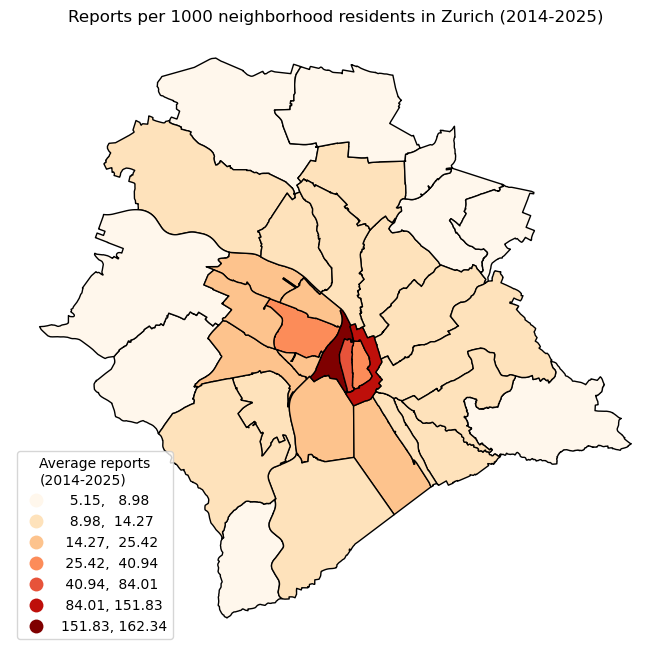

NaturalBreaks

    Interval       Count
------------------------
[  5.15,   8.98] |     9
(  8.98,  14.27] |    13
( 14.27,  25.42] |     7
( 25.42,  40.94] |     2
( 40.94,  84.01] |     1
( 84.01, 151.83] |     1
(151.83, 162.34] |     1

In [96]:
create_choropleth(
    normalized_reports_map,
    "reports_per_1000",
    title = "Reports per 1000 neighborhood residents in Zurich (2014-2025)",
    legend_title = "Average reports\n(2014-2025)",
    output_path = "../outputs/normalized_reports_zurich_2014-2025_map.png",
    k=7,
    classification="NaturalBreaks"
)

We can also show the normalized reports of all neighborhoods (2014-2025) with a bar plot.

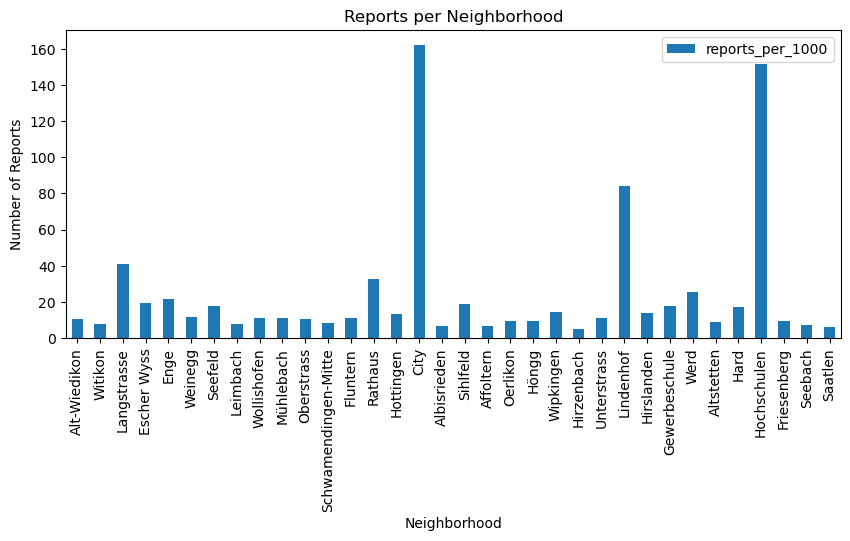

In [ ]:
# plot the reports per neighborhood in a bar plot
normalized_reports_map.plot(
    kind="bar",
    x="qname",
    y="reports_per_1000",
    figsize=(10,4)
)

plt.title("Reports per Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Number of Reports")
plt.show()